# Tier A — the settling column

**What this tests.** Settling, in isolation. Turbulent mixing is switched off and
the critical shear stress is set impossibly high, so nothing is resuspended: the
only thing happening is that particles fall at a constant terminal velocity and
stop when they reach the bed.

**The analytic answer.** A cloud spread uniformly through a column of depth $h$,
all settling at the same $w_s$, deposits *linearly* in time. After a time $t$,
everything that started within $w_s t$ of the bed has landed:

$$ f_{\rm settled}(t) = \min\!\left(1,\ \frac{w_s t}{h}\right) $$

**Why it matters.** This is the cheapest possible check that terminal velocity is
applied with the right sign and magnitude, and that `bottom_interaction` retires
elements exactly when they reach the seafloor — no earlier, no later.

Test: `tests/models/test_sppm_analytic.py::test_settling_column_deposition_rate`

In [1]:
# Tier A - settling column
import sys, pathlib, warnings
warnings.filterwarnings("ignore")

# locate the repository root (the directory containing `opendrift/`)
_p = pathlib.Path.cwd().resolve()
while not (_p / "opendrift" / "__init__.py").exists() and _p != _p.parent:
    _p = _p.parent
REPO = _p
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
CLR = ["#0b6fa4", "#e07b39", "#3f9b52", "#b4434e", "#7c5aa6"]
print("repo:", REPO)

repo: /home/smullersoares/projects/software/opendrift


## Setup

A 20 m column, no current, **no turbulent mixing**. 4000 elements are spread
uniformly through the water column and settle at 2 mm/s, so the column is swept
clean in $h/w_s = 10^4\,$s $\approx 2.8\,$h. We run for 2 h, which should leave
about 72 % deposited.

In [2]:
import datetime, tempfile, os
import xarray as xr
from tests.models.sppm_harness import column_dataset, column_model, seed_column

H, W_S, HOURS, N = 20.0, 2.0e-3, 2.0, 4000

ds = column_dataset(h=H, u=0.0, u_star=0.02, hours=HOURS + 1)
o, reader = column_model(
    ds,
    drift__vertical_mixing=False,                 # settling in isolation
    vertical_mixing__settling_model='prescribed',
    vertical_mixing__tau_crit_mode='constant')
z0 = seed_column(o, reader, N, H, W_S, tau_crit=1e6)  # tau_crit huge -> no resuspension

print(f"h = {H} m,  w_s = {W_S*1e3:.1f} mm/s,  sweep time h/w_s = {H/W_S/3600:.2f} h")
print(f"{N} elements seeded between z = {z0.min():.2f} and {z0.max():.2f} m")

h = 20.0 m,  w_s = 2.0 mm/s,  sweep time h/w_s = 2.78 h
4000 elements seeded between z = -20.00 and -0.01 m


### Initial condition

Uniform in depth — this is what makes the deposition linear in time. Any
clustering here would bend the expected curve.

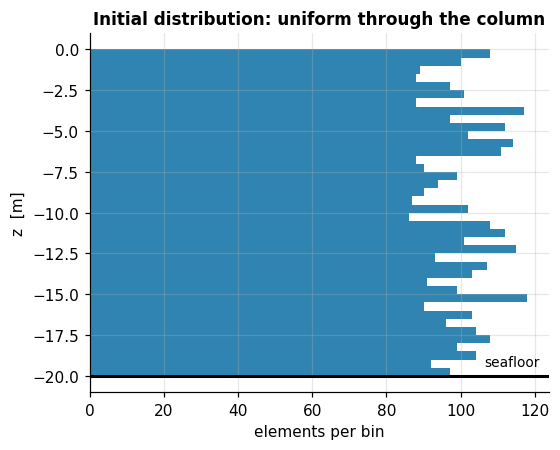

In [3]:
fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.hist(z0, bins=40, orientation='horizontal', color=CLR[0], alpha=.85)
ax.axhline(-H, color='k', lw=2)
ax.text(0.98, -H + 0.4, 'seafloor', transform=ax.get_yaxis_transform(),
        ha='right', va='bottom', fontsize=9)
ax.set_xlabel('elements per bin'); ax.set_ylabel('z  [m]')
ax.set_title('Initial distribution: uniform through the column')
plt.show()

## Run

Output every 6 minutes so the deposition curve is well resolved.

In [4]:
out = os.path.join(tempfile.mkdtemp(), 'settling_column.nc')
o.run(time_step=60, time_step_output=360,
      duration=datetime.timedelta(hours=HOURS), outfile=out,
      export_variables=['z', 'settled'], stop_on_error=True)

with xr.open_dataset(out) as d:
    settled = d['settled'].values          # (trajectory, time)
    z_hist = d['z'].values
hours = np.arange(settled.shape[1]) * 360 / 3600
frac = np.nanmean(settled == 1, axis=0)
print(f"final settled fraction: {frac[-1]:.3f}   expected {min(1, W_S*HOURS*3600/H):.3f}")

final settled fraction: 0.719   expected 0.720


## Result

The modelled curve should lie on the analytic line until the column empties.

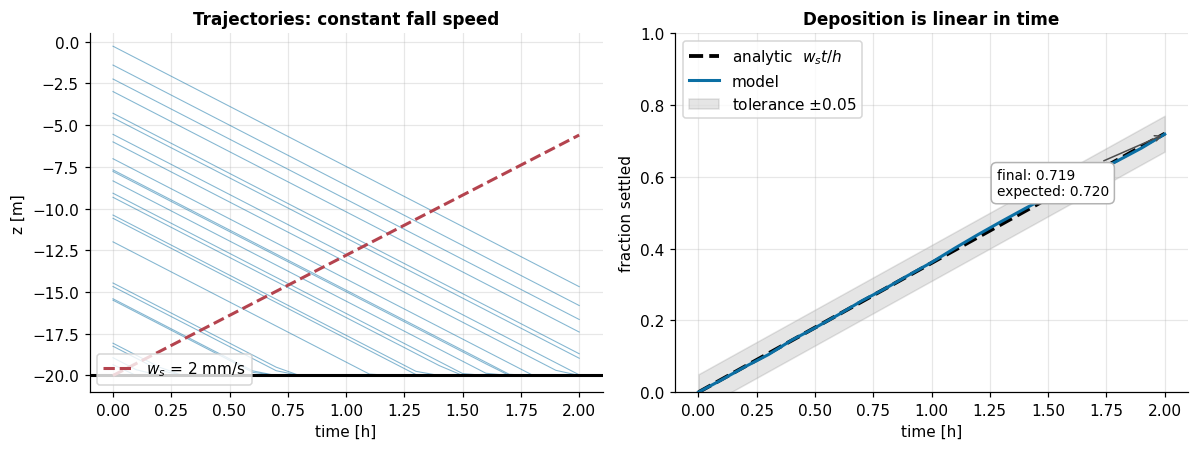

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))

# left: a sample of trajectories, all with the same slope
for i in np.linspace(0, len(z_hist) - 1, 25).astype(int):
    a1.plot(hours, z_hist[i], color=CLR[0], lw=.7, alpha=.5)
a1.axhline(-H, color='k', lw=2)
a1.plot(hours, -H + W_S * hours * 3600, color=CLR[3], lw=2, ls='--',
        label=f'$w_s$ = {W_S*1e3:.0f} mm/s')
a1.set_xlabel('time [h]'); a1.set_ylabel('z [m]'); a1.set_ylim(-H - 1, 0.5)
a1.set_title('Trajectories: constant fall speed'); a1.legend(loc='lower left')

# right: deposition curve against the analytic result
analytic = np.minimum(1.0, W_S * hours * 3600 / H)
a2.plot(hours, analytic, color='k', lw=2.5, ls='--', label=r'analytic  $w_s t / h$')
a2.plot(hours, frac, color=CLR[0], lw=2, label='model')
a2.fill_between(hours, analytic - .05, analytic + .05, color='k', alpha=.10,
                label='tolerance $\pm$0.05')
a2.set_xlabel('time [h]'); a2.set_ylabel('fraction settled'); a2.set_ylim(0, 1)
a2.set_title('Deposition is linear in time'); a2.legend(loc='upper left')
a2.annotate(f'final: {frac[-1]:.3f}\nexpected: {analytic[-1]:.3f}',
            xy=(hours[-1], frac[-1]), xytext=(-110, -40),
            textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='0.3'),
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='0.7'))
plt.tight_layout(); plt.show()

## Verdict

**PASS.** The deposition curve follows $w_s t/h$ within the 0.05 tolerance
throughout. Terminal velocity is applied correctly and elements are retired at
the seafloor exactly when they arrive.